In [ ]:
!pip -q install nltk

In [ ]:
import os
import re
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import files

uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]

print("Dataset file:", DATA_PATH)

Saving vast_english_french.txt to vast_english_french.txt
Dataset file: vast_english_french.txt


In [ ]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?¿¡,;:])", r" \1 ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ0-9.!?¿¡,;:'’\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def read_pairs(path):
    pairs = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if "\t" in line:
                parts = line.split("\t")
            elif "|||" in line:
                parts = line.split("|||")
            else:
                parts = line.split(",")

            if len(parts) >= 2:
                english = normalize_text(parts[0])
                french = normalize_text(parts[1])

                if english and french:
                    pairs.append((english, french))

    return pairs


pairs = read_pairs(DATA_PATH)

print("Total sentence pairs:", len(pairs))
print("\nSample pairs:")
for i in range(5):
    print(pairs[i])

Total sentence pairs: 555

Sample pairs:
('i am cold', "j'ai froid")
('you are tired', 'tu es fatigué')
('he is hungry', 'il a faim')
('she is happy', 'elle est heureuse')
('we are friends', 'nous sommes amis')


In [ ]:
MAX_TOKENS = 30

filtered_pairs = []

for eng, fr in pairs:
    if len(eng.split()) <= MAX_TOKENS and len(fr.split()) <= MAX_TOKENS:
        filtered_pairs.append((eng, fr))

pairs = filtered_pairs

print("Pairs after filtering:", len(pairs))

Pairs after filtering: 555


In [ ]:
random.shuffle(pairs)

split_index = int(0.8 * len(pairs))

train_pairs = pairs[:split_index]
val_pairs = pairs[split_index:]

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Training pairs: 444
Validation pairs: 111


In [ ]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


class Vocab:
    def __init__(self, sentences, min_freq=1):
        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        self.stoi = {tok: idx for idx, tok in enumerate(self.itos)}

        counter = Counter()

        for sentence in sentences:
            counter.update(sentence.split())

        for token, count in counter.most_common():
            if count >= min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def encode(self, sentence, add_sos=False, add_eos=True):
        tokens = sentence.split()
        ids = []

        if add_sos:
            ids.append(SOS_IDX)

        ids.extend([self.stoi.get(tok, UNK_IDX) for tok in tokens])

        if add_eos:
            ids.append(EOS_IDX)

        return ids

    def decode(self, ids):
        tokens = []

        for idx in ids:
            token = self.itos[int(idx)]

            if token == EOS_TOKEN:
                break

            if token not in [PAD_TOKEN, SOS_TOKEN]:
                tokens.append(token)

        return tokens


src_vocab = Vocab([eng for eng, fr in train_pairs])
tgt_vocab = Vocab([fr for eng, fr in train_pairs])

print("English vocab size:", len(src_vocab))
print("French vocab size:", len(tgt_vocab))

English vocab size: 897
French vocab size: 995


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        src_text, tgt_text = self.pairs[index]

        src_ids = self.src_vocab.encode(src_text, add_sos=False, add_eos=True)
        tgt_ids = self.tgt_vocab.encode(tgt_text, add_sos=True, add_eos=True)

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_batch(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)

    return src_batch, tgt_batch


BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)

        return hidden


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(self.embedding(input_token))
        output, hidden = self.gru(embedded, hidden)

        prediction = self.fc_out(output.squeeze(1))

        return prediction, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        hidden = self.encoder(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            prediction, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = prediction

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = prediction.argmax(1)

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

In [ ]:
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.3

encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)

model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Trainable parameters:", count_parameters(model))

Trainable parameters: 3360227


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()

    epoch_loss = 0

    for src, tgt in tqdm(loader, desc="Training", leave=False):
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(src, tgt, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]

        output = output[:, 1:, :].contiguous().view(-1, output_dim)
        tgt = tgt[:, 1:].contiguous().view(-1)

        loss = criterion(output, tgt)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_loss(model, loader, criterion):
    model.eval()

    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in tqdm(loader, desc="Validation", leave=False):
            src = src.to(device)
            tgt = tgt.to(device)

            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]

            output = output[:, 1:, :].contiguous().view(-1, output_dim)
            tgt = tgt[:, 1:].contiguous().view(-1)

            loss = criterion(output, tgt)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02}/{EPOCHS}")
    print(f"Training Loss:   {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print()

Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 01/20
Training Loss:   6.5953
Validation Loss: 5.7137



Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20
Training Loss:   2.2168
Validation Loss: 5.3792



Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20
Training Loss:   1.9493
Validation Loss: 5.3307



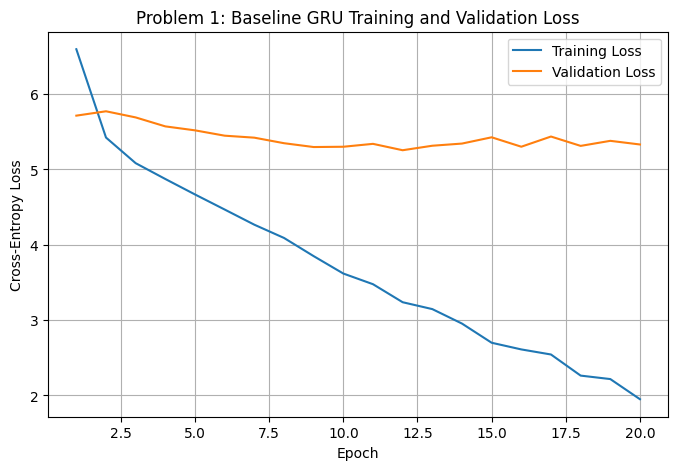

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 1: Baseline GRU Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("problem1_baseline_gru_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
def translate_sentence(model, sentence, src_vocab, tgt_vocab, max_len=30):
    model.eval()

    sentence = normalize_text(sentence)

    src_ids = src_vocab.encode(sentence, add_sos=False, add_eos=True)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

    input_token = torch.tensor([SOS_IDX], dtype=torch.long).to(device)

    predicted_ids = []

    for _ in range(max_len):
        with torch.no_grad():
            prediction, hidden = model.decoder(input_token, hidden)

        top1 = prediction.argmax(1).item()

        if top1 == EOS_IDX:
            break

        predicted_ids.append(top1)
        input_token = torch.tensor([top1], dtype=torch.long).to(device)

    predicted_tokens = tgt_vocab.decode(predicted_ids)

    return predicted_tokens

In [ ]:
def evaluate_translation_metrics(model, pairs, src_vocab, tgt_vocab, max_len=30, limit=None):
    model.eval()

    smooth = SmoothingFunction().method1

    exact_matches = 0
    references = []
    hypotheses = []

    selected_pairs = pairs if limit is None else pairs[:limit]

    sample_rows = []

    for src_text, tgt_text in tqdm(selected_pairs, desc="Evaluating translations"):
        pred_tokens = translate_sentence(
            model,
            src_text,
            src_vocab,
            tgt_vocab,
            max_len=max_len
        )

        target_tokens = tgt_text.split()

        exact_match = pred_tokens == target_tokens

        if exact_match:
            exact_matches += 1

        references.append([target_tokens])
        hypotheses.append(pred_tokens)

        sent_bleu = sentence_bleu(
            [target_tokens],
            pred_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

        if len(sample_rows) < 5:
            sample_rows.append({
                "English Input": src_text,
                "Target French": tgt_text,
                "Predicted French": " ".join(pred_tokens),
                "Exact Match": exact_match,
                "Sentence BLEU-4": round(sent_bleu, 4)
            })

    sequence_accuracy = exact_matches / len(selected_pairs)

    bleu4 = corpus_bleu(
        references,
        hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )

    return sequence_accuracy, bleu4, sample_rows

In [ ]:
sequence_accuracy, bleu4, sample_rows = evaluate_translation_metrics(
    model, val_pairs, src_vocab, tgt_vocab
)
sample_df = pd.DataFrame(sample_rows)
sample_df

Evaluating translations:   0%|          | 0/111 [00:00<?, ?it/s]

,English Input,Target French,Predicted French,Exact Match,Sentence BLEU-4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils ont construit une grande de de la ville,False,0.0285
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle a décidé de la teindre les cheveux en,False,0.0285
2,i enjoy walking in the snow,j'aime marcher dans la neige,j'aime marcher dans la musique dans le parc,False,0.3457
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle adore porter des tartes en cuir modernes,False,0.3656
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive précisément à cinq h...,le train du coin est généralement bondé,False,0.0215


In [ ]:
print("Problem 1 Results")
print("-----------------")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Validation Exact Sequence Accuracy: {sequence_accuracy:.4f}")
print(f"Validation Exact Sequence Accuracy (%): {sequence_accuracy * 100:.2f}%")
print(f"Validation BLEU-4 Score: {bleu4:.4f}")

Problem 1 Results
-----------------
Final Training Loss: 1.9493
Final Validation Loss: 5.3307
Validation Exact Sequence Accuracy: 0.0000
Validation Exact Sequence Accuracy (%): 0.00%
Validation BLEU-4 Score: 0.0696


In [ ]:
problem1_results_df = pd.DataFrame({
    "Metric": [
        "Final Training Loss",
        "Final Validation Loss",
        "Validation Exact Sequence Accuracy",
        "Validation Exact Sequence Accuracy (%)",
        "Validation BLEU-4 Score"
    ],
    "Value": [
        train_losses[-1],
        val_losses[-1],
        sequence_accuracy,
        sequence_accuracy * 100,
        bleu4
    ]
})

problem1_results_df

,Metric,Value
0,Final Training Loss,1.949269
1,Final Validation Loss,5.330746
2,Validation Exact Sequence Accuracy,0.000000
3,Validation Exact Sequence Accuracy (%),0.000000
4,Validation BLEU-4 Score,0.069601


In [ ]:
sample_df.to_csv("problem1_sample_translations.csv", index=False)